In [1]:
import example_loader as el
import gurobipy as gp
import gurobi_utils as gu
import miplib_loader as ml
import numpy as np
import plot_utils as pu
import importlib as il

%matplotlib inline

Starting instance 2D from bottom
  Adding GMI cut: <gurobi.Constr R2>
  Adding GMI cut: <gurobi.Constr R3>
  Adding GMI cut: <gurobi.Constr R4>
  Adding GMI cut: <gurobi.Constr R5>


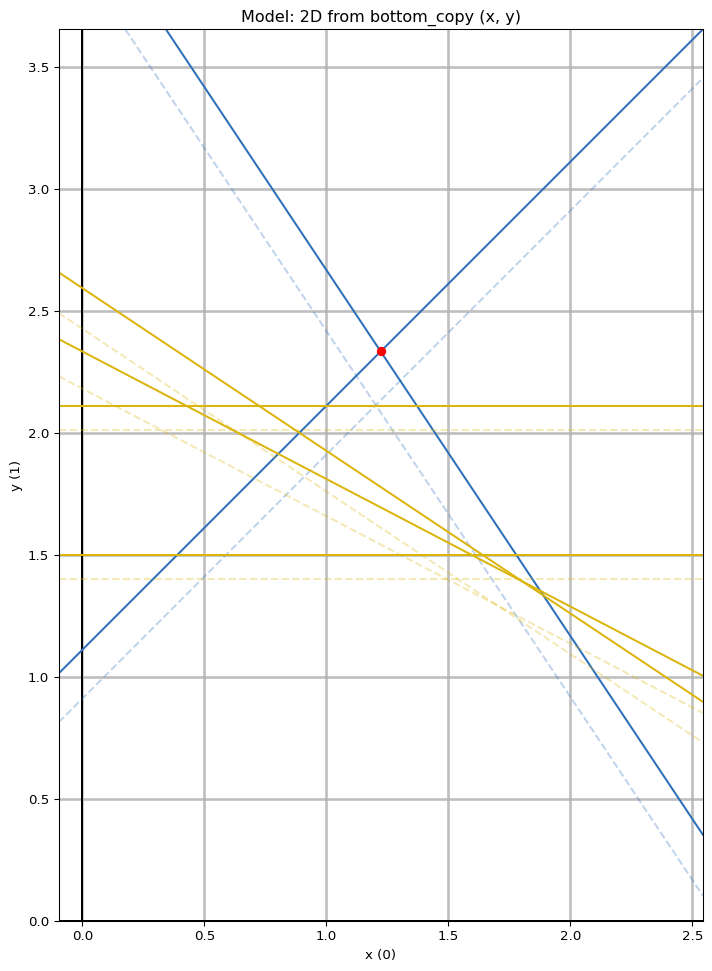

Starting instance 2D no easy cut from bottom
  Adding GMI cut: <gurobi.Constr R2>
  Adding GMI cut: <gurobi.Constr R3>
  Adding GMI cut: <gurobi.Constr R4>
  Adding GMI cut: <gurobi.Constr R5>
  Adding GMI cut: <gurobi.Constr R6>


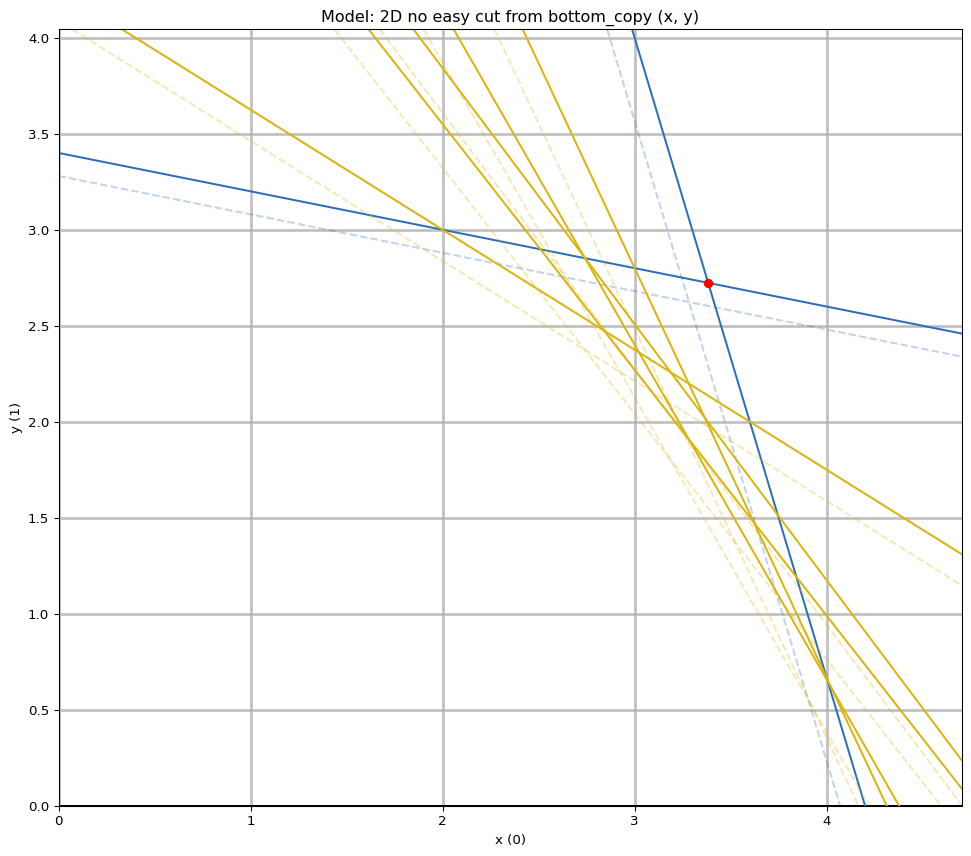

Starting instance 2D steep from bottom
  Adding GMI cut: <gurobi.Constr R2>
  Adding GMI cut: <gurobi.Constr R3>
  Adding GMI cut: <gurobi.Constr R4>
  Adding GMI cut: <gurobi.Constr R5>
  Adding GMI cut: <gurobi.Constr R6>


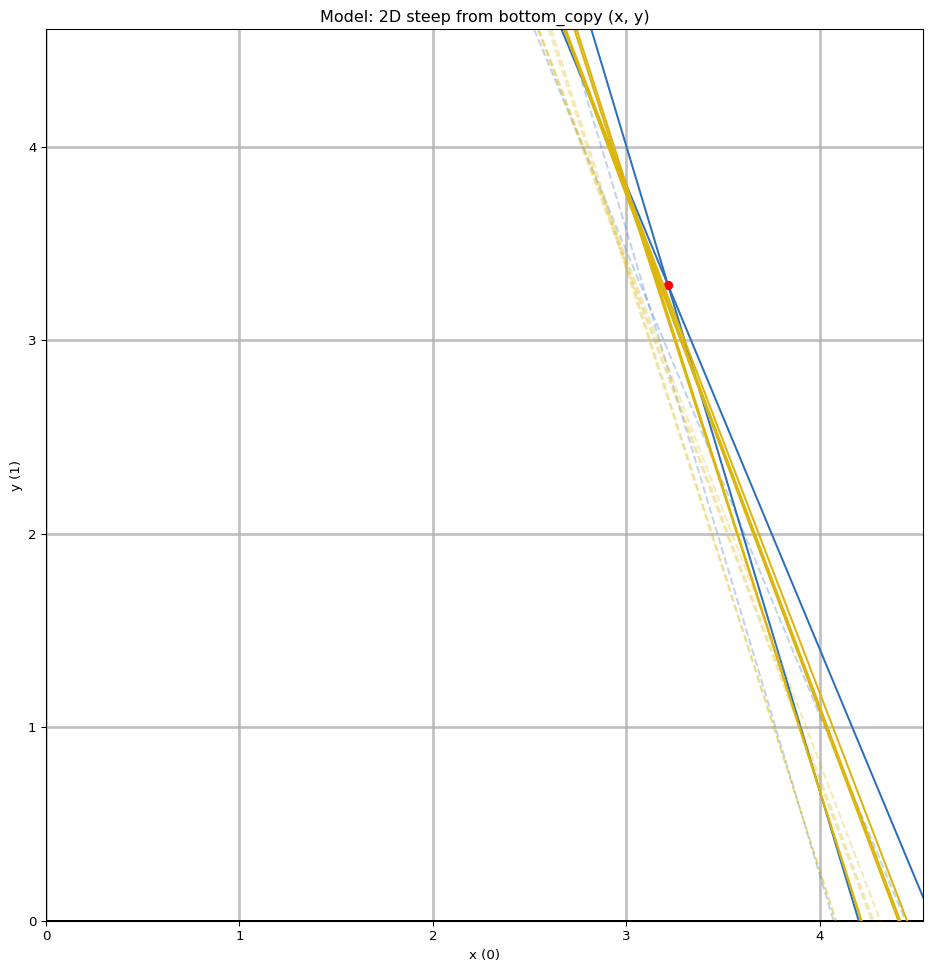

Starting instance 2D from top
  Adding GMI cut: <gurobi.Constr R2>
  Adding GMI cut: <gurobi.Constr R3>
  Adding GMI cut: <gurobi.Constr R4>
  Adding GMI cut: <gurobi.Constr R5>


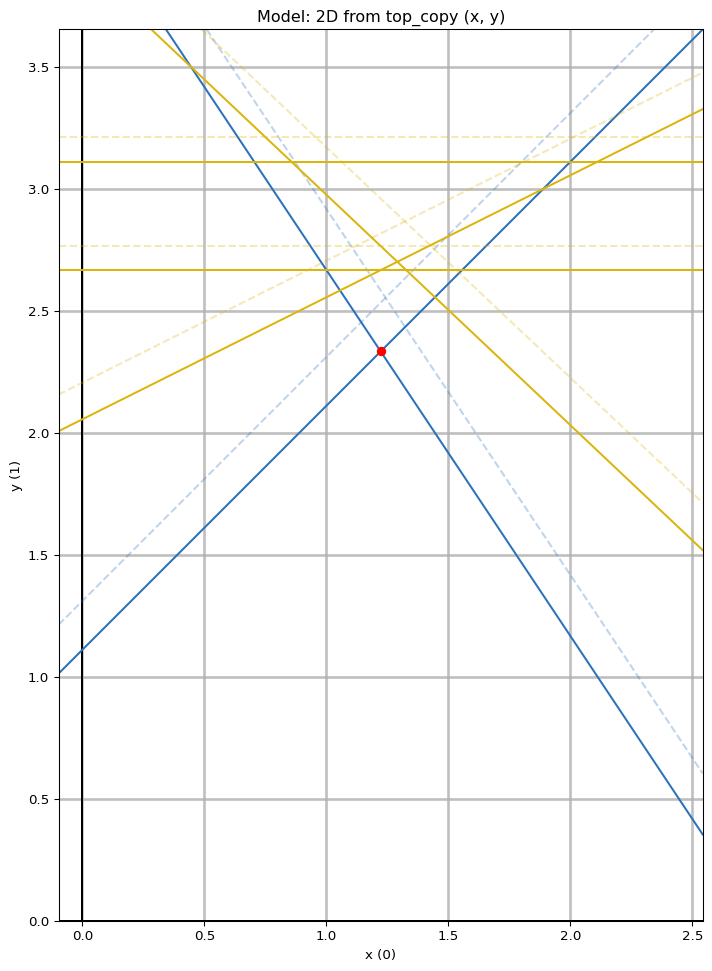

Starting instance 2D from bottom (upper bounded x)
  Adding GMI cut: <gurobi.Constr R2>
  Adding GMI cut: <gurobi.Constr R3>


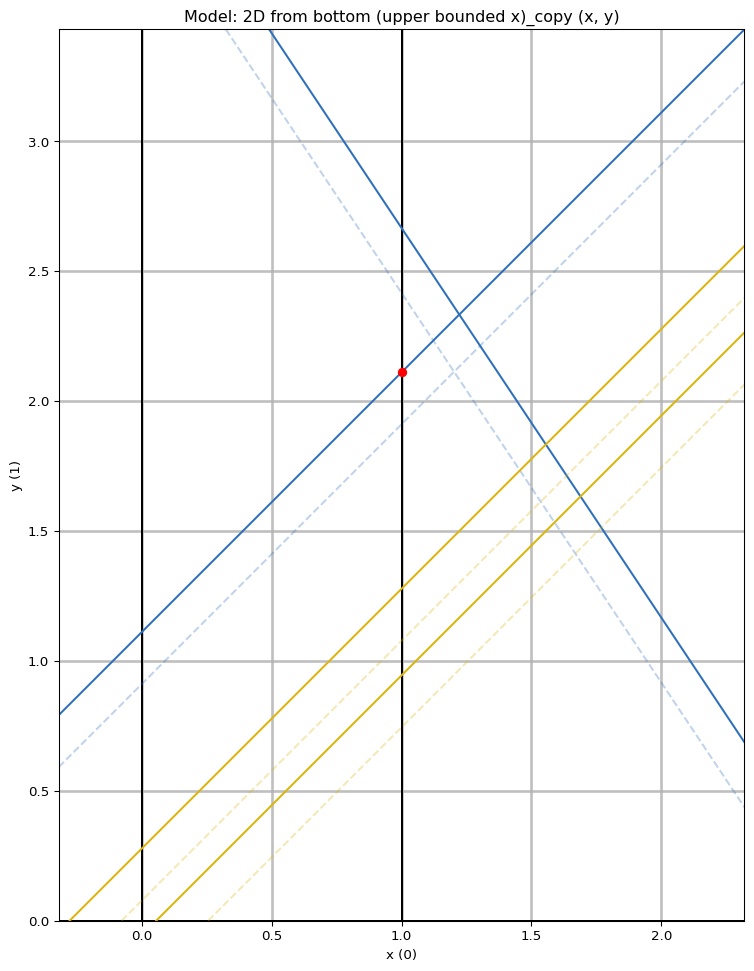

Starting instance 2D from bottom (steep, y<=2)
  Adding GMI cut: <gurobi.Constr R2>
  Adding GMI cut: <gurobi.Constr R3>


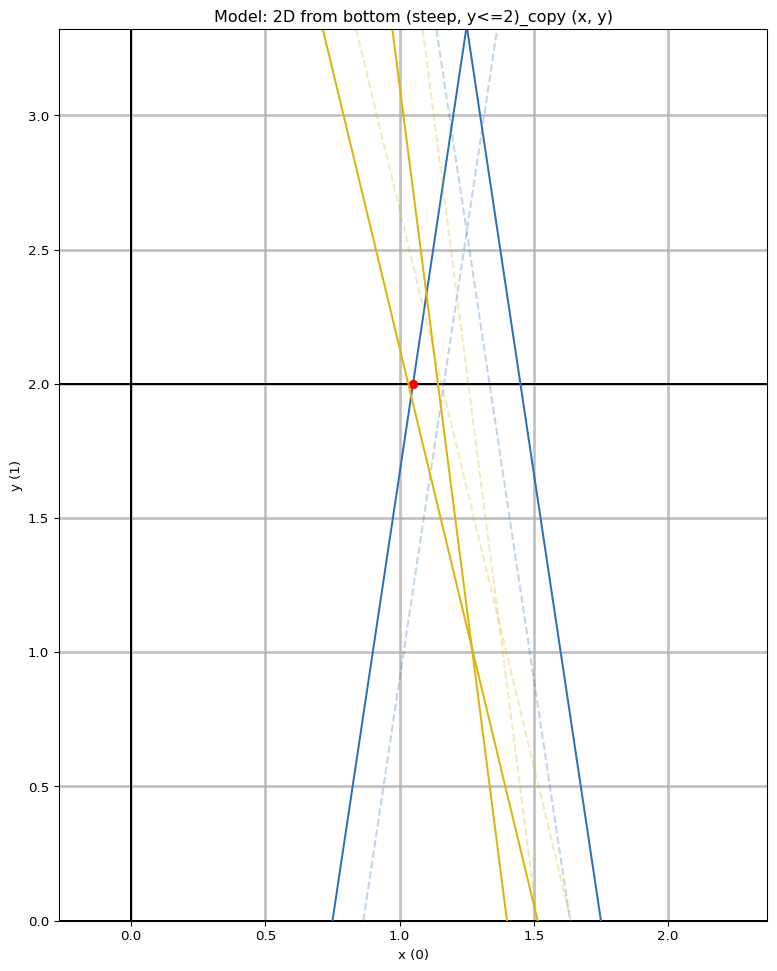

In [ ]:
il.reload(gu)
def run_gmi_cuts(model: gp.Model, rounds):
    int_var_idx = {v.index for v in model.getVars() if v.VType in (gp.GRB.INTEGER, gp.GRB.BINARY)}
    relaxed = model.relax()
    relaxed.params.Presolve = 0  # for reading the tableau
    relaxed.params.LogToConsole = 0
    relaxed.optimize()
    plotter = pu.create(relaxed)
    if plotter is not None:
        plotter.add_ball(1.2)
    starting_obj = relaxed.ObjVal
    for r in range(rounds):
        basis, tableau, col_to_var_idx, x = gu.transform_to_original_variables_try2(relaxed)
        basis2, tableau2, col_to_var_idx2, x2 = gu.transform_to_original_variables(relaxed)
        # if all x are integer, we are done:
        if np.allclose(x[list(int_var_idx), 0], np.round(x[list(int_var_idx), 0]), atol=relaxed.params.FeasibilityTol):
            print("  All integer variables are integral; stopping GMI cut generation at round", r)
            break
        # variables, constraints = gu.fix_tableau_dirs(relaxed, tableau, col_to_var_idx)
        variables, constraints = relaxed.getVars(), relaxed.getConstrs()
        constraints_to_add = gu.make_gmi_cuts(basis, tableau, col_to_var_idx, x, int_var_idx, variables, 
                                              constraints, relaxed, fix_signs=False, tol=relaxed.params.FeasibilityTol)
        relaxed.addConstrs(c for c in constraints_to_add)
        relaxed.optimize()
        if plotter is not None:
            for c in relaxed.getConstrs()[len(constraints):]:
                print("  Adding GMI cut:", c)
                plotter.add_constraint(c)
        if relaxed.status != gp.GRB.Status.OPTIMAL:
            print("  GMI cut generation stopped early due to non-optimal relaxation. Status:", gu.status_lookup.get(relaxed.status, relaxed.status))
            return starting_obj, "unknown", relaxed.NumConstrs - model.NumConstrs, plotter

    return starting_obj, relaxed.ObjVal, relaxed.NumConstrs - model.NumConstrs, plotter

env = gp.Env(empty=True)
env.setParam('OutputFlag', 0)
env.start()
instances = [e.as_gurobi_model() for e in list(el.get_instances(env=env).values())[0:6]]
for model in instances:
    print("Starting instance", model.ModelName)
    # gu.standardize_gt_to_lt(model)
    start, end, num_cuts, plotter = run_gmi_cuts(model, rounds=1)
    if plotter is not None:
        plotter.render()
